**Install required libraries**

In [ ]:
!pip install -q transformers datasets scikit-learn pandas seaborn matplotlib tqdm

# **Dataset**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
label
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64


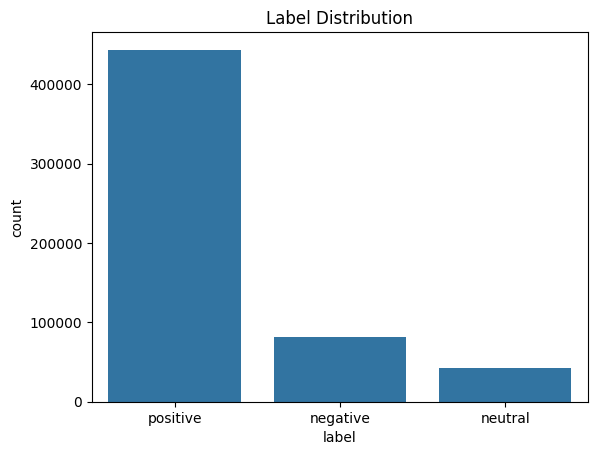

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Project1 (Sentiment Analysis on Amazon Product Reviews)/Reviews.csv", on_bad_lines='skip')
df = df[['Text','Score']].dropna()
df.rename(columns={'Text':'text','Score':'score'}, inplace=True)

# Map numeric scores to sentiment labels
def map_label(s):
    if s <= 2:
        return 'negative'
    elif s == 3:
        return 'neutral'
    else:
        return 'positive'

df['label'] = df['score'].apply(map_label)

# Display label distribution
print(df['label'].value_counts())
sns.countplot(data=df, x='label')
plt.title("Label Distribution")
plt.show()

 **Dataset İnfo**

- 568,000 Amazon product reviews  
- 443777 Positive, 82037 Negative, 42640 Neutral Review
- Source: Amazon open data  
- Score used as ground truth (1–5 → sentiment)  

# **Dataset Preprocessing**

In [ ]:
import re
from sklearn.model_selection import train_test_split

# Text Cleaning Function
# Removes URLs, special characters, and converts to lowercase

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^A-Za-z0-9(),!?\'\`]", " ", text)
    text = text.lower()
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

# Split into train/validation/test (80/10/10)
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1111, stratify=train_val['label'], random_state=42)

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

Train: 454768, Validation: 56840, Test: 56846


**Preprocessing Steps**

1. Removed URLs and special characters  
2. Converted text to lowercase  
3. Split dataset into train (80%)(454768), validation (10%)(56480), test (10%)(56846)

In [ ]:
df.head()

,text,score,label,clean_text
0,I have bought several of the Vitality canned d...,5,positive,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,1,negative,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,4,positive,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,2,negative,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,5,positive,great taffy at a great price there was a wid...


# **Method 0: Naive Bayes**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

nb_model.fit(train['clean_text'], train['label'])
nb_preds = nb_model.predict(val['clean_text'])

nb_acc = accuracy_score(val['label'], nb_preds)
nb_f1 = f1_score(val['label'], nb_preds, average='macro')

print("Naive Bayes Results")
print("Accuracy:", nb_acc)
print("F1 Score:", nb_f1)
print(classification_report(val['label'], nb_preds))

Naive Bayes Results
Accuracy: 0.8661857846586911
F1 Score: 0.6164596279760223
              precision    recall  f1-score   support

    negative       0.80      0.61      0.70      8203
     neutral       0.64      0.14      0.23      4264
    positive       0.88      0.98      0.93     44373

    accuracy                           0.87     56840
   macro avg       0.77      0.58      0.62     56840
weighted avg       0.85      0.87      0.84     56840



**Naive Bayes Results**
- Accuracy ≈ 0.86  
- F1 Score ≈ 0.61  
*Interpretation:* Good baseline performance but struggles with neutral reviews.

# **Method 1: Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_model.fit(train['clean_text'], train['label'])
lr_preds = lr_model.predict(val['clean_text'])

lr_acc = accuracy_score(val['label'], lr_preds)
lr_f1 = f1_score(val['label'], lr_preds, average='macro')

print("Logistic Regression Results")
print("Accuracy:", lr_acc)
print("F1 Score:", lr_f1)
print(classification_report(val['label'], lr_preds))

Logistic Regression Results
Accuracy: 0.869018296973962
F1 Score: 0.74982306997771
              precision    recall  f1-score   support

    negative       0.76      0.84      0.80      8203
     neutral       0.40      0.72      0.52      4264
    positive       0.98      0.89      0.93     44373

    accuracy                           0.87     56840
   macro avg       0.72      0.82      0.75     56840
weighted avg       0.91      0.87      0.88     56840



**Logistic Regression Results**
- Accuracy ≈ 0.86  
- F1 Score ≈ 0.74  
*Interpretation:* Handles text patterns better than Naive Bayes.

# **Method 2: DistilBERT**

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np


# Pretrained model fine-tuned for sentiment classification.
# DistilBERT is a smaller, faster version of BERT.


label_list = ['negative','neutral','positive']
label2id = {v:k for k,v in enumerate(label_list)}
id2label = {k:v for k,v in enumerate(label_list)}

train_ds = Dataset.from_pandas(train[['clean_text','label']])
val_ds = Dataset.from_pandas(val[['clean_text','label']])

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def encode_data(example):
    return tokenizer(example['clean_text'], truncation=True, padding='max_length', max_length=256)

def encode_label(example):
    example['labels'] = label_list.index(example['label'])
    return example

train_ds = train_ds.map(encode_label).map(encode_data, batched=True)
val_ds = val_ds.map(encode_label).map(encode_data, batched=True)

cols_to_remove = ['clean_text','label']
train_ds = train_ds.remove_columns(cols_to_remove)
val_ds = val_ds.remove_columns(cols_to_remove)
train_ds.set_format("torch")
val_ds.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
results = trainer.evaluate(val_ds)
print(results)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1688818095.py:63: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24efe-cetin (24efe-cetin-i-stinye-niversitesi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.208000,0.206231,0.928695,0.808537
2,0.164500,0.211415,0.936612,0.831660


{'eval_loss': 0.2062307447195053, 'eval_accuracy': 0.9286945812807882, 'eval_f1': 0.8085374159585815, 'eval_runtime': 96.0481, 'eval_samples_per_second': 591.787, 'eval_steps_per_second': 18.501, 'epoch': 2.0}


**DistilBERT Results**

- Accuracy ≈ 0.92  
- F1 Score ≈ 0.80  
*Interpretation:* Transformer model captures contextual meaning and provides the best performance.

# **Results and Conclusions**

                 Model  Accuracy  F1-Score
0          Naive Bayes  0.866186  0.616460
1  Logistic Regression  0.869018  0.749823
2           DistilBERT  0.928695  0.808537


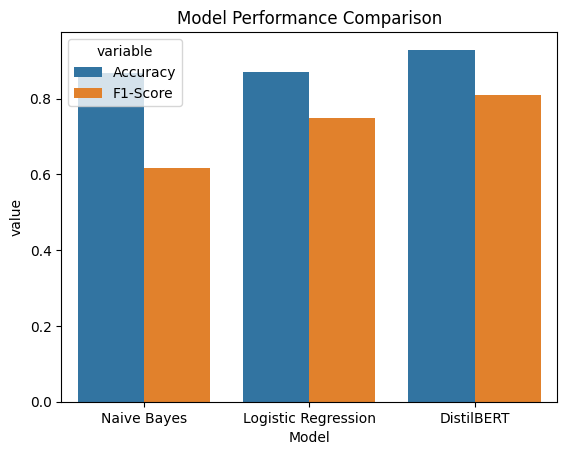

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "DistilBERT"],
    "Accuracy": [nb_acc, lr_acc, results["eval_accuracy"]],
    "F1-Score": [nb_f1, lr_f1, results["eval_f1"]]
})
print(results_df)
sns.barplot(data=results_df.melt(id_vars="Model"), x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison")
plt.show()